# Visibility Distance Prediction
**Life cycle of Machine learning Project**

* Understanding the Problem Statement
* Data Collection
* Data Cleaning
* Exploratory data analysis
* Data Pre-Processing
* Model Training 
* Choose best model


## 1) Problem statement.

* **ATC** wants to track the weather and predict the visibility distance. To fly the planes the visibility distance is very much important, that is why this project is very much crucial.


### **What is Visibility Distance Prediction?**

* Visibility distance, that means how far any object can be seen from. Based on various climate forcasting parameters, we can predict the visibility distance with machine learning techniques.


## 2. Data Collection
- The data is collected from various sources and dumped into mongodb for our purpose. We have merged the dataset and will work on the data analysis on top of that.

### Feature Information

- **DATE** - 
- **VISIBILITY** - Distance from which can objecy can be seen.
- **DRYBULBTEMPF** - Dry bulb temperature (degrees Farenheit). Most commonly reported standard temperature. 
- **WETBULBTEMPF** - Wet bulb temperature (degrees Farenheit )
- **DewPointTempF** - Dew point temperature ( degrees Farenheit )
- **RelativeHumidity** - Relative humidity (percent )
- **WindSpeed** - Wind speed (miles per hour )
- **WindDirection** - Wind direction from true north using compass directions.
- **StationPressure** - Atmospheric pressure (inches of Mercury; or 'in Hg').
- **SeaLevelPressure** - Sea level pressure ( in Hg).
- **Precip** - Total precipitation in the past hour (in inches )

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Data\data.csv')

In [3]:
df.head()

,DATE,VISIBILITY,DRYBULBTEMPF,WETBULBTEMPF,DewPointTempF,RelativeHumidity,WindSpeed,WindDirection,StationPressure,SeaLevelPressure,Precip
0,2010-01-01 00:51:00,6.0,33,32,31,92,0,0,29.97,29.99,0.01
1,2010-01-01 01:51:00,6.0,33,33,32,96,0,0,29.97,29.99,0.02
2,2010-01-01 02:51:00,5.0,33,33,32,96,0,0,29.97,29.99,0.02
3,2010-01-01 03:51:00,5.0,33,33,32,96,0,0,29.95,29.97,0.02
4,2010-01-01 04:51:00,5.0,33,32,31,92,0,0,29.93,29.96,0.02


In [4]:
df.isnull().sum()

DATE                0
VISIBILITY          0
DRYBULBTEMPF        0
WETBULBTEMPF        0
DewPointTempF       0
RelativeHumidity    0
WindSpeed           0
WindDirection       0
StationPressure     0
SeaLevelPressure    0
Precip              0
dtype: int64

**REPORT**
There are no null values

In [5]:
df.dtypes

DATE                 object
VISIBILITY          float64
DRYBULBTEMPF          int64
WETBULBTEMPF          int64
DewPointTempF         int64
RelativeHumidity      int64
WindSpeed             int64
WindDirection         int64
StationPressure     float64
SeaLevelPressure    float64
Precip              float64
dtype: object

In [6]:
df['DATE']=df['DATE'].astype('object')

In [7]:
df.dtypes

DATE                 object
VISIBILITY          float64
DRYBULBTEMPF          int64
WETBULBTEMPF          int64
DewPointTempF         int64
RelativeHumidity      int64
WindSpeed             int64
WindDirection         int64
StationPressure     float64
SeaLevelPressure    float64
Precip              float64
dtype: object

In [8]:
df.shape

(75083, 11)

In [9]:
df['DATE']=pd.to_datetime(df['DATE'],format='%Y-%m-%d %H:%M:%S')

In [10]:
df

,DATE,VISIBILITY,DRYBULBTEMPF,WETBULBTEMPF,DewPointTempF,RelativeHumidity,WindSpeed,WindDirection,StationPressure,SeaLevelPressure,Precip
0,2010-01-01 00:51:00,6.0,33,32,31,92,0,0,29.97,29.99,0.01
1,2010-01-01 01:51:00,6.0,33,33,32,96,0,0,29.97,29.99,0.02
2,2010-01-01 02:51:00,5.0,33,33,32,96,0,0,29.97,29.99,0.02
3,2010-01-01 03:51:00,5.0,33,33,32,96,0,0,29.95,29.97,0.02
4,2010-01-01 04:51:00,5.0,33,32,31,92,0,0,29.93,29.96,0.02
...,...,...,...,...,...,...,...,...,...,...,...
75078,2018-07-27 18:51:00,10.0,76,73,72,88,3,230,30.00,30.02,0.00
75079,2018-07-27 19:51:00,4.0,69,69,69,100,13,40,29.99,30.01,1.16
75080,2018-07-27 20:51:00,10.0,71,70,70,96,0,0,30.02,30.04,0.01
75081,2018-07-27 21:51:00,10.0,72,71,70,94,5,50,30.00,30.02,0.01


In [11]:
df['DATE']

0       2010-01-01 00:51:00
1       2010-01-01 01:51:00
2       2010-01-01 02:51:00
3       2010-01-01 03:51:00
4       2010-01-01 04:51:00
                ...        
75078   2018-07-27 18:51:00
75079   2018-07-27 19:51:00
75080   2018-07-27 20:51:00
75081   2018-07-27 21:51:00
75082   2018-07-27 22:51:00
Name: DATE, Length: 75083, dtype: datetime64[ns]

In [12]:
# define numerical & categorical columns
#Let's drop the ID column

columns=[column for column in df.columns if column!='VISIBILITY'] #target column

numerical_features=[feature for feature in columns if df[feature].dtype!='O']

categorical_features=[feature for feature in columns if df[feature].dtype=='O']

In [13]:
numerical_features

['DATE',
 'DRYBULBTEMPF',
 'WETBULBTEMPF',
 'DewPointTempF',
 'RelativeHumidity',
 'WindSpeed',
 'WindDirection',
 'StationPressure',
 'SeaLevelPressure',
 'Precip']

In [14]:
categorical_features

[]

## Univariate Analysis

* The term univariate analysis refers to the analysis of one variable prefix “uni” means “one.” The purpose of univariate analysis is to understand the distribution of values for a single variable.

Other Type of Analysis are
* **Bivariate Analysis:** The analysis of two variables.
* **Multivariate Analysis:** The analysis of two or more variables.

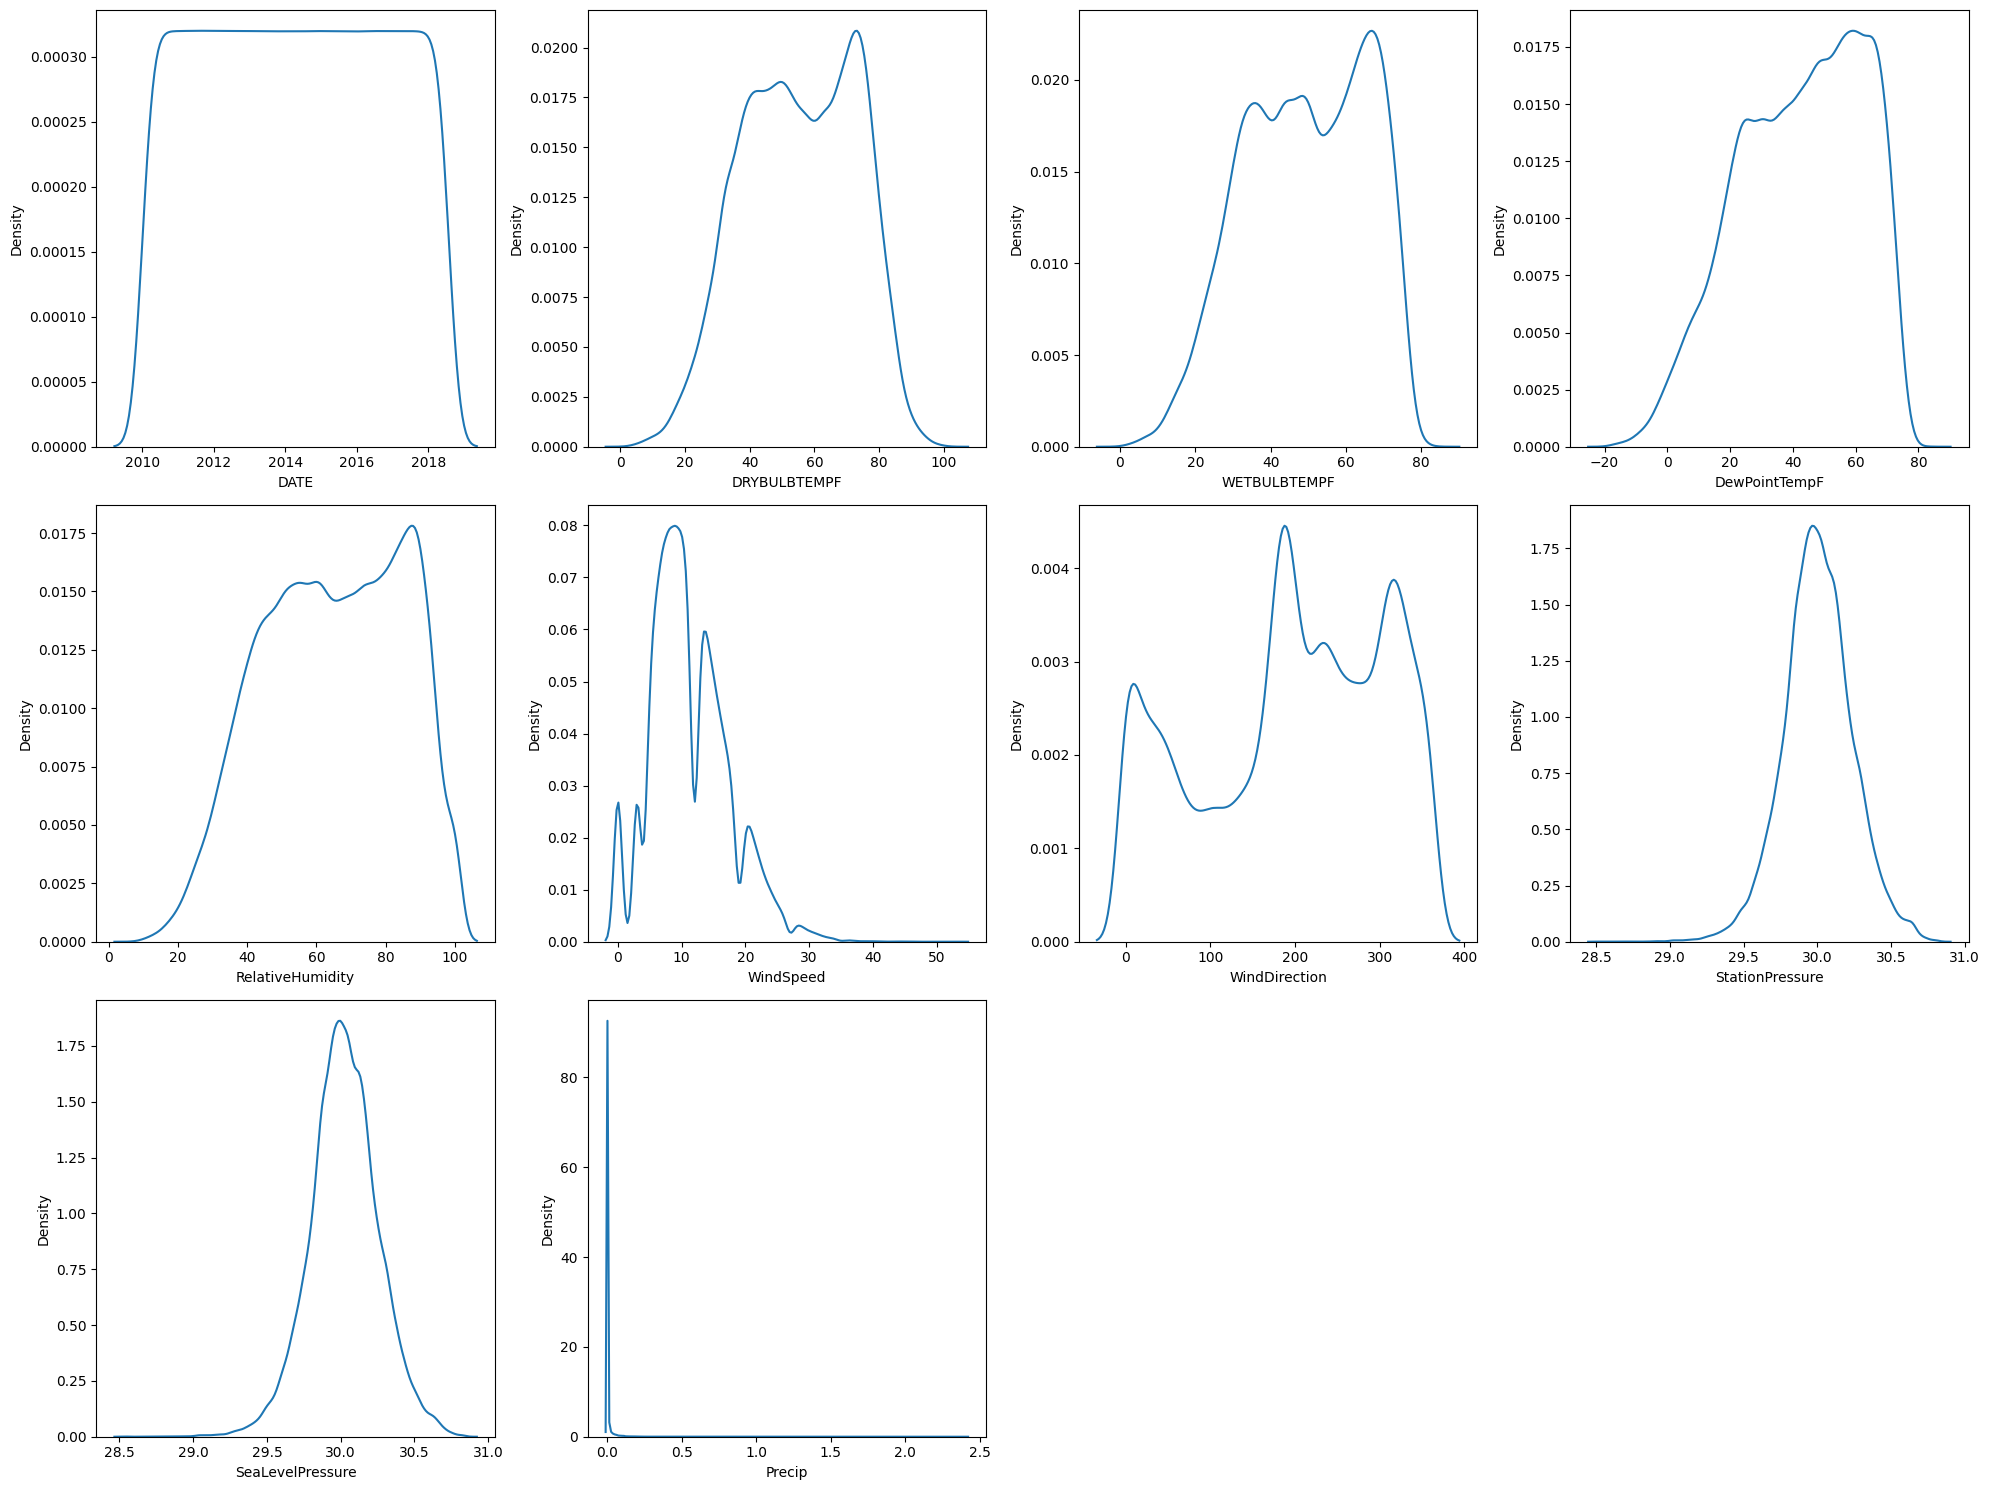

In [15]:
plt.figure(figsize=(20,15))

for i in range(0,len(numerical_features)):
    plt.subplot(3,4,i+1)
    sns.kdeplot(x=df[numerical_features[i]])
    plt.xlabel(numerical_features[i])
    plt.tight_layout()

In [16]:
df.columns

Index(['DATE', 'VISIBILITY', 'DRYBULBTEMPF', 'WETBULBTEMPF', 'DewPointTempF',
       'RelativeHumidity', 'WindSpeed', 'WindDirection', 'StationPressure',
       'SeaLevelPressure', 'Precip'],
      dtype='object')

*Report of the univariate analytis*
1. `DATE`:-Most of the values fall bw 2010-2018 and has outliers
2. `DRYBULBTEMPF`:-most of the values fall bw 20 and 100 and has outliers
3. `WETBULBTEMPF DewPointTempF`:-most of the values fall bw 10 to 80 and has outliers and its left skewd
4. `RelativeHumidity`:-left skewd and most of the values lie 20-100 
5. `WindSpeed`:-Its a right skewd and has outliers most values fall in 0-35
6. `WindDirection`:-is scattered most of the values fall in bw 0-50 and has outliers
7. `StationPressure`,`SeaLevelPressure` are following a normal distribution and has some outliers.
8. `Precip`is seems to be right skewed, although most of the values are ranging near 0.

### Multivariate Analysis
* Multivariate analysis is the analysis of more than one variable.

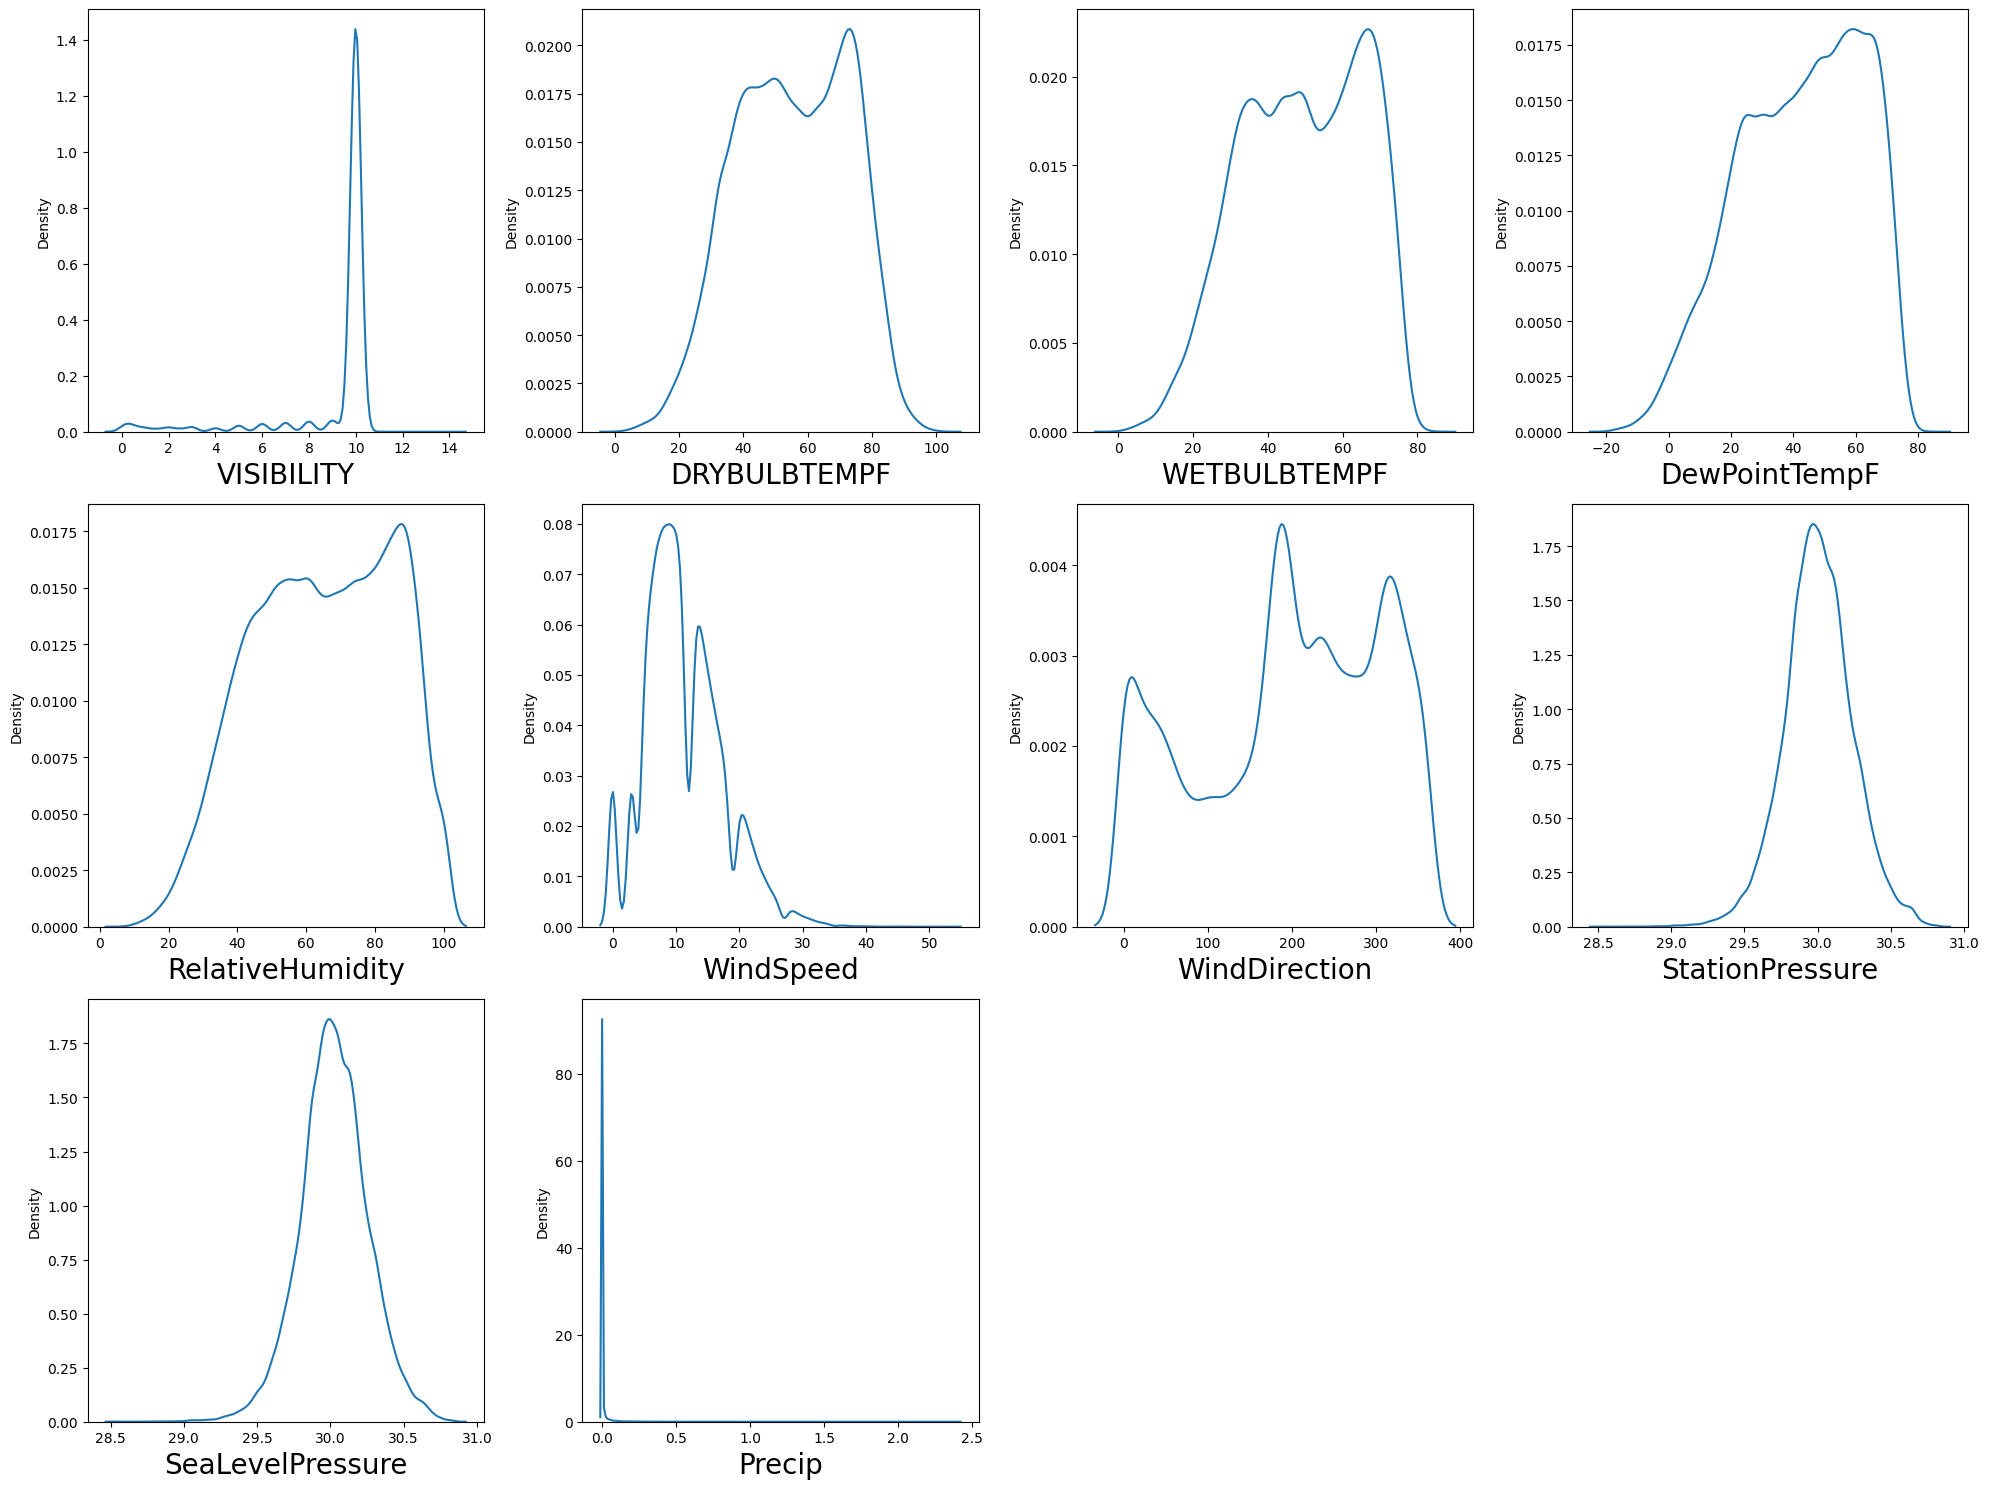

In [17]:
plt.figure(figsize=(20,15))
plotnumber=1

for column in df.drop(['DATE'],axis=1):
    plt.subplot(3,4,plotnumber)
    sns.kdeplot(df[column])
    plt.xlabel(column,fontsize=20)
    plotnumber=plotnumber+1
plt.tight_layout()



We can see some columns are not following normal distribution.

we will use such algorithms which do not require normal distribution such as decision tree and XGBoost.

Also, precipitation column has most of data value near 0. It won't be very useful for our analysis. 
Let's drop this column.

In [18]:

df = df.drop(columns='Precip')

<Axes: >

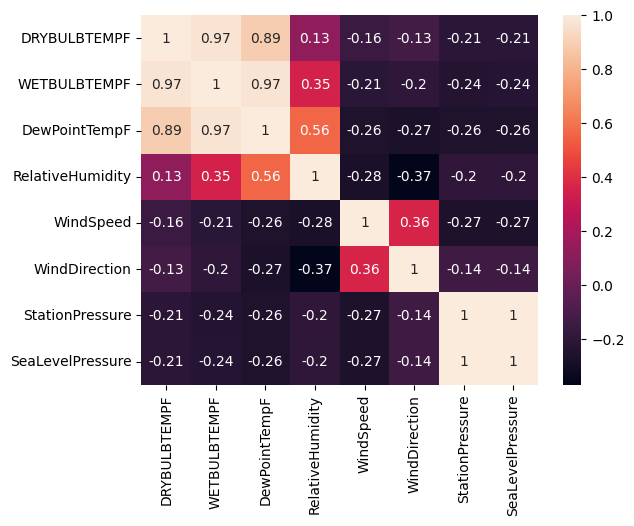

In [19]:
plt_data=df.drop(columns=['VISIBILITY','DATE']).corr()
sns.heatmap(plt_data,annot=True)

In [20]:
df=df.drop(['WETBULBTEMPF','DewPointTempF','StationPressure'],axis=1)

<Axes: >

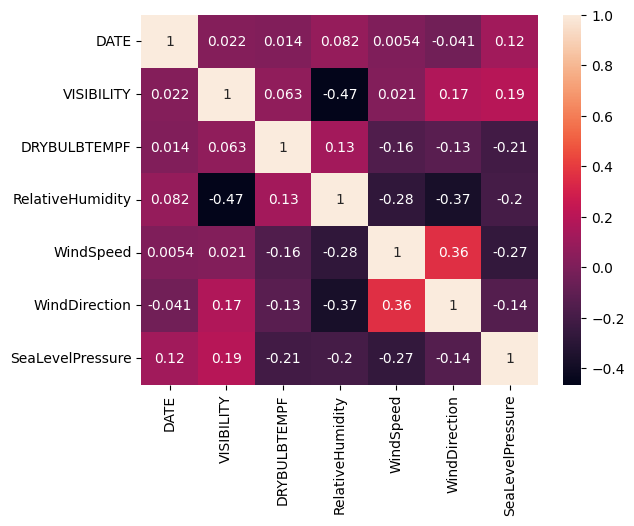

In [21]:
sns.heatmap(df.corr(),annot=True)

### Multicollinearity Check
#### Variance Inflation Factor (VIF)
* Multicollinearity occurs when there are two or more independent variables in a multiple regression model, which have a high correlation among themselves. When some features are highly correlated.
* Multicollinearity can be detected using various techniques, one such technique being the Variance Inflation Factor(VIF).

In [22]:
df=df.drop('DATE',axis=1)

In [23]:
df.head()

,VISIBILITY,DRYBULBTEMPF,RelativeHumidity,WindSpeed,WindDirection,SeaLevelPressure
0,6.0,33,92,0,0,29.99
1,6.0,33,96,0,0,29.99
2,5.0,33,96,0,0,29.99
3,5.0,33,96,0,0,29.97
4,5.0,33,92,0,0,29.96


In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(considered_features,df):
    X=df[considered_features]
    X['intercept']=1


    vif=pd.DataFrame()
    vif['VARIABLES']=X.columns
    vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
    vif=vif[vif['VARIABLES']!='intercept']
    return vif

features=df.columns.to_list()
compute_vif(features,df)

,VARIABLES,VIF
0,VISIBILITY,1.341907
1,DRYBULBTEMPF,1.141377
2,RelativeHumidity,1.609773
3,WindSpeed,1.348445
4,WindDirection,1.310169
5,SeaLevelPressure,1.318955


### We can see the data has no such collinearity

## Analysis Report
* **There are no missing values in the dataset.**
* **The precip column can be deleted because the values can be considered as 0.**
* **There are some columns which are correlated with each other, so we dropped those.**